# Show-Alignment Visualizer

Visual exploration for `data/processed/show-alignment_*.txt` artifacts.

This notebook parses the text report and renders:
- per-run WER summary charts
- sample-level comparisons
- color-coded token alignment tables (match/substitution/insertion/deletion)

In [1]:
from __future__ import annotations

import os
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
from IPython.display import HTML, display

ROOT = Path.cwd().resolve().parents[0] if Path.cwd().name == "analysis" else Path.cwd().resolve()
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

from analysis.alignment_viz import (  # noqa: E402
    build_run_summary_df,
    parse_show_alignment_report,
    render_alignment_html,
)

sns.set_theme(style="whitegrid")
pd.set_option("display.max_colwidth", 200)

In [2]:
# Parameters
REPORT_PATH = os.getenv(
    "ALIGNMENT_REPORT_PATH",
    "../data/processed/show-alignment_20260402T101843Z.txt",
)
SAMPLE_ID = os.getenv("SAMPLE_ID", "") or None
MAX_CHUNKS_PER_RUN = int(os.getenv("MAX_CHUNKS_PER_RUN", "4"))

print("report:", REPORT_PATH)
print("sample_id:", SAMPLE_ID)
print("max_chunks_per_run:", MAX_CHUNKS_PER_RUN)

report: data/processed/show-alignment_20260403T094016Z.txt
sample_id: D0420-S1-T01
max_chunks_per_run: 6


In [3]:
parsed = parse_show_alignment_report(REPORT_PATH)
summary_df = build_run_summary_df(parsed)

print("samples parsed:", len(parsed["samples"]))
print("rows:", len(summary_df))
summary_df.head()

samples parsed: 43
rows: 86


,sample_id,run_id_short,wer,substitutions,insertions,deletions,ref_words,chunks
0,D0420-S1-T01,e7fc04ce…,0.2394,203,104,420,3037,66
1,D0420-S1-T01,50a52f67…,0.1900,115,26,436,3037,64
2,D0420-S1-T02,e7fc04ce…,0.1796,20,6,78,579,13
3,D0420-S1-T02,50a52f67…,0.1641,21,6,68,579,13
4,D0420-S1-T03,e7fc04ce…,0.1513,33,2,122,1038,22


In [4]:
meta = parsed.get("meta", {})
meta

{'candidate_run_id': 'e7fc04ce-2cb2-427a-afa2-e456438abf8f',
 'baseline_run_id': '50a52f67-abce-47b6-939e-271013b3a4e0',
 'candidate_model': 'mlx-community/whisper-large-v3-mlx',
 'baseline_model': 'mlx-community/whisper-large-v3-turbo'}

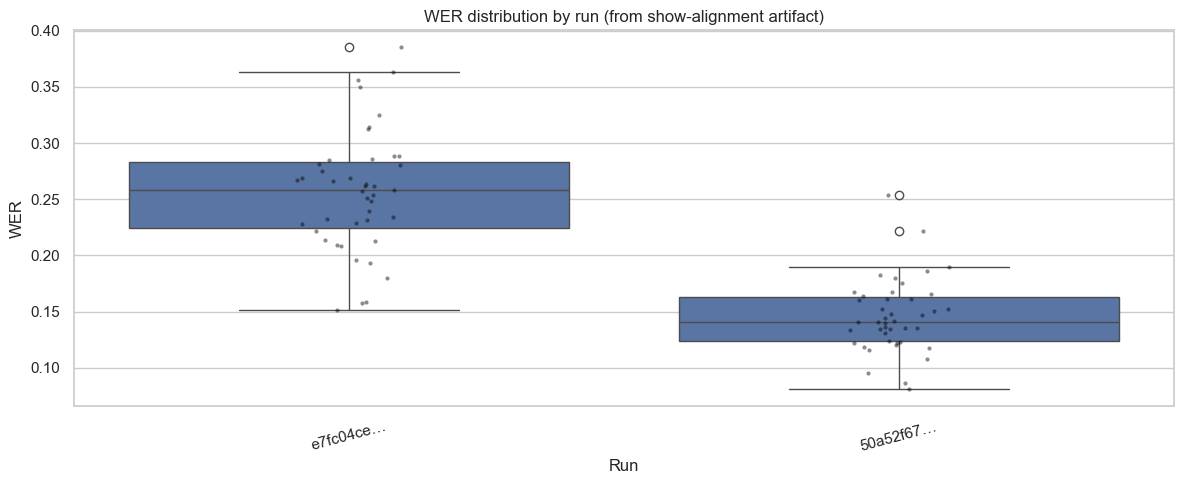

In [5]:
if not summary_df.empty:
    plt.figure(figsize=(12, 5))
    sns.boxplot(data=summary_df, x="run_id_short", y="wer")
    sns.stripplot(data=summary_df, x="run_id_short", y="wer", color="black", alpha=0.45, size=3)
    plt.title("WER distribution by run (from show-alignment artifact)")
    plt.xlabel("Run")
    plt.ylabel("WER")
    plt.xticks(rotation=15)
    plt.tight_layout()
    plt.show()

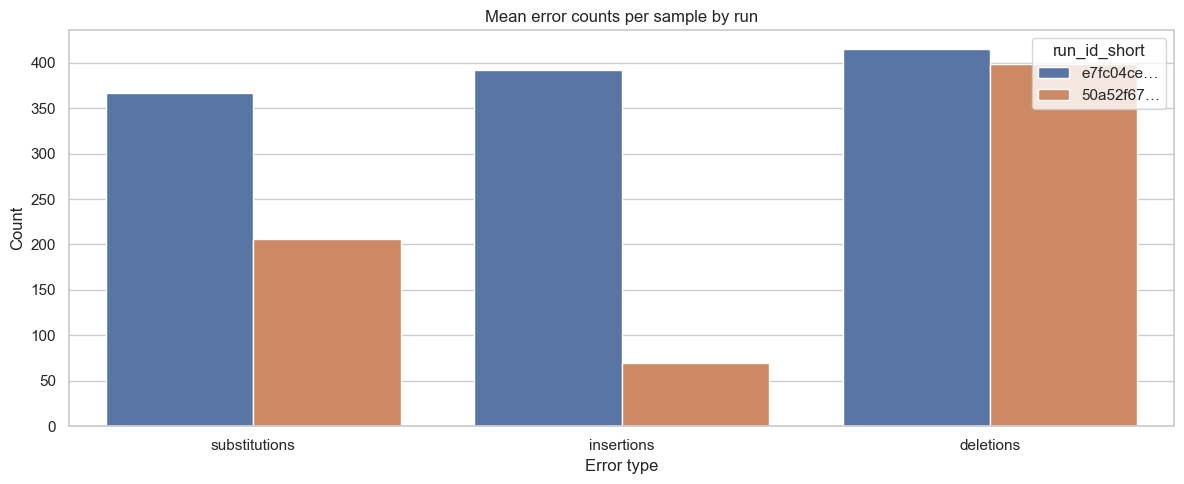

In [6]:
if not summary_df.empty:
    ops = summary_df.copy()
    ops["error_total"] = ops["substitutions"] + ops["insertions"] + ops["deletions"]
    melted = ops.melt(
        id_vars=["sample_id", "run_id_short"],
        value_vars=["substitutions", "insertions", "deletions"],
        var_name="error_type",
        value_name="count",
    )
    plt.figure(figsize=(12, 5))
    sns.barplot(data=melted, x="error_type", y="count", hue="run_id_short", estimator="mean", errorbar=None)
    plt.title("Mean error counts per sample by run")
    plt.xlabel("Error type")
    plt.ylabel("Count")
    plt.tight_layout()
    plt.show()

run_id_short,sample_id,50a52f67…,e7fc04ce…,wer_delta_r1_minus_r2
33,D0422-S3-T05,0.1186,0.3502,0.2316
18,D0421-S3-T01,0.1616,0.3850,0.2234
14,D0421-S1-T04,0.0952,0.2889,0.1937
8,D0420-S3-T03,0.0868,0.2636,0.1768
26,D0422-S1-T04,0.1415,0.3143,0.1728
13,D0421-S1-T03,0.1161,0.2883,0.1722
30,D0422-S3-T02,0.1861,0.3564,0.1703
15,D0421-S1-T05,0.0811,0.2514,0.1703
20,D0421-S3-T03,0.1675,0.3247,0.1572
19,D0421-S3-T02,0.1604,0.3122,0.1518


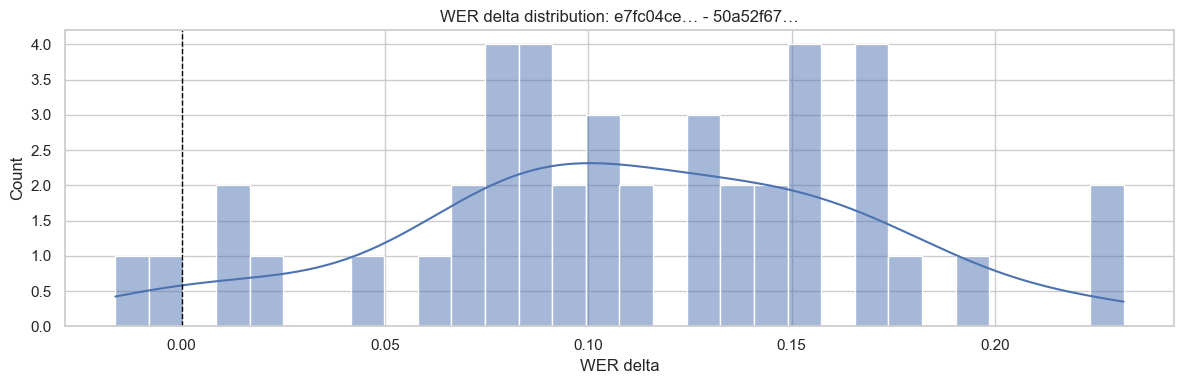

In [7]:
# Candidate-vs-baseline sample delta if both runs exist
if not summary_df.empty and summary_df["run_id_short"].nunique() >= 2:
    ordered_runs = list(summary_df["run_id_short"].dropna().unique())
    r1, r2 = ordered_runs[0], ordered_runs[1]
    pivot = summary_df.pivot_table(index="sample_id", columns="run_id_short", values="wer", aggfunc="mean").reset_index()
    if r1 in pivot.columns and r2 in pivot.columns:
        pivot["wer_delta_r1_minus_r2"] = pivot[r1] - pivot[r2]
        display(pivot.sort_values("wer_delta_r1_minus_r2", ascending=False).head(20))
        plt.figure(figsize=(12, 4))
        sns.histplot(pivot["wer_delta_r1_minus_r2"].dropna(), bins=30, kde=True)
        plt.axvline(0, linestyle="--", color="black", linewidth=1)
        plt.title(f"WER delta distribution: {r1} - {r2}")
        plt.xlabel("WER delta")
        plt.tight_layout()
        plt.show()

## Token-Level Visual Alignment

Choose a sample and render the first N alignment chunks for each run.

Color legend:
- green: match (`=`)
- orange: substitution (`S`)
- blue: insertion (`I`)
- red: deletion (`D`)

In [8]:
available_samples = [s.sample_id for s in parsed["samples"]]
print(f"available samples: {len(available_samples)}")
print("first 20:", available_samples[:20])

target_sample = SAMPLE_ID or (available_samples[0] if available_samples else None)
print("target_sample:", target_sample)

available samples: 43
first 20: ['D0420-S1-T01', 'D0420-S1-T02', 'D0420-S1-T03', 'D0420-S1-T04', 'D0420-S1-T05', 'D0420-S2-T01', 'D0420-S3-T01', 'D0420-S3-T02', 'D0420-S3-T03', 'D0420-S4-T01', 'D0420-S4-T02', 'D0421-S1-T01', 'D0421-S1-T02', 'D0421-S1-T03', 'D0421-S1-T04', 'D0421-S1-T05', 'D0421-S2-T01', 'D0421-S2-T02', 'D0421-S3-T01', 'D0421-S3-T02']
target_sample: D0420-S1-T01


In [9]:
if target_sample is None:
    raise ValueError("No samples were parsed from this report.")

sample_obj = next((s for s in parsed["samples"] if s.sample_id == target_sample), None)
if sample_obj is None:
    raise ValueError(f"sample_id {target_sample} not found in report")

for run in sample_obj.runs:
    display(HTML(render_alignment_html(run, max_chunks=MAX_CHUNKS_PER_RUN)))

OP,GOLD,HYP
D,speaker,·
D,1,·
D,dialogue,·
=,i,i
=,am,am
=,the,the
=,psychiatrist,psychiatrist
=,here,here
=,in,in
=,this,this


OP,GOLD,HYP
D,speaker,·
D,1,·
D,dialogue,·
=,i,i
=,am,am
=,the,the
=,psychiatrist,psychiatrist
=,here,here
=,in,in
=,this,this
